In [1]:
import zipfile
import os

with zipfile.ZipFile("hr.zip", "r") as zip_ref:
    zip_ref.extractall("/content/hr_data")

print(os.listdir("/content/hr_data"))

['employee_data.csv', 'recruitment_data.csv', 'employee_engagement_survey_data.csv', 'training_and_development_data.csv']


In [2]:
import pandas as pd

employee = pd.read_csv("/content/hr_data/employee_data.csv")
engagement = pd.read_csv("/content/hr_data/employee_engagement_survey_data.csv")
recruitment = pd.read_csv("/content/hr_data/recruitment_data.csv")
training = pd.read_csv("/content/hr_data/training_and_development_data.csv")

print("Employee:", employee.shape)
print("Engagement:", engagement.shape)
print("Recruitment:", recruitment.shape)
print("Training:", training.shape)

Employee: (3000, 26)
Engagement: (3000, 5)
Recruitment: (3000, 18)
Training: (3000, 9)


In [3]:
print("EMPLOYEE")
print(employee.columns.tolist())

print("\nENGAGEMENT")
print(engagement.columns.tolist())

print("\nRECRUITMENT")
print(recruitment.columns.tolist())

print("\nTRAINING")
print(training.columns.tolist())


EMPLOYEE
['EmpID', 'FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title', 'Supervisor', 'ADEmail', 'BusinessUnit', 'EmployeeStatus', 'EmployeeType', 'PayZone', 'EmployeeClassificationType', 'TerminationType', 'TerminationDescription', 'DepartmentType', 'Division', 'DOB', 'State', 'JobFunctionDescription', 'GenderCode', 'LocationCode', 'RaceDesc', 'MaritalDesc', 'Performance Score', 'Current Employee Rating']

ENGAGEMENT
['Employee ID', 'Survey Date', 'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score']

RECRUITMENT
['Applicant ID', 'Application Date', 'First Name', 'Last Name', 'Gender', 'Date of Birth', 'Phone Number', 'Email', 'Address', 'City', 'State', 'Zip Code', 'Country', 'Education Level', 'Years of Experience', 'Desired Salary', 'Job Title', 'Status']

TRAINING
['Employee ID', 'Training Date', 'Training Program Name', 'Training Type', 'Training Outcome', 'Location', 'Trainer', 'Training Duration(Days)', 'Training Cost']


In [4]:
print("Employee IDs:", employee["EmpID"].head().tolist())
print("Engagement IDs:", engagement["Employee ID"].head().tolist())
print("Training IDs:", training["Employee ID"].head().tolist())

Employee IDs: [3427, 3428, 3429, 3430, 3431]
Engagement IDs: [1001, 1002, 1003, 1004, 1005]
Training IDs: [1001, 1002, 1003, 1004, 1005]


In [6]:
print("Employee ID range:", employee["EmpID"].min(), employee["EmpID"].max())
print("Engagement ID range:", engagement["Employee ID"].min(), engagement["Employee ID"].max())
print("Training ID range:", training["Employee ID"].min(), training["Employee ID"].max())

Employee ID range: 1001 4000
Engagement ID range: 1001 4000
Training ID range: 1001 4000


In [7]:
print(employee["EmployeeStatus"].value_counts())

EmployeeStatus
Active                    2458
Voluntarily Terminated     321
Leave of Absence            86
Future Start                69
Terminated for Cause        66
Name: count, dtype: int64


In [8]:
df = employee.merge(
    engagement,
    left_on="EmpID",
    right_on="Employee ID",
    how="left"
)

df = df.merge(
    training,
    left_on="EmpID",
    right_on="Employee ID",
    how="left"
)

print(df.shape)
print(df.head())

(3000, 40)
   EmpID FirstName LastName  StartDate ExitDate                    Title  \
0   3427     Uriah  Bridges  20-Sep-19      NaN  Production Technician I   
1   3428     Paula    Small  11-Feb-23      NaN  Production Technician I   
2   3429    Edward     Buck  10-Dec-18      NaN       Area Sales Manager   
3   3430   Michael  Riordan  21-Jun-21      NaN       Area Sales Manager   
4   3431   Jasmine    Onque  29-Jun-19      NaN       Area Sales Manager   

        Supervisor                        ADEmail BusinessUnit EmployeeStatus  \
0     Peter Oneill    uriah.bridges@bilearner.com         CCDR         Active   
1  Renee Mccormick      paula.small@bilearner.com           EW         Active   
2   Crystal Walker      edward.buck@bilearner.com           PL         Active   
3   Rebekah Wright  michael.riordan@bilearner.com         CCDR         Active   
4        Jason Kim    jasmine.onque@bilearner.com          TNS         Active   

   ... Work-Life Balance Score Employee ID_y 

In [9]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
EmpID                            0
FirstName                        0
LastName                         0
StartDate                        0
ExitDate                      1467
Title                            0
Supervisor                       0
ADEmail                          0
BusinessUnit                     0
EmployeeStatus                   0
EmployeeType                     0
PayZone                          0
EmployeeClassificationType       0
TerminationType                  0
TerminationDescription        1467
DepartmentType                   0
Division                         0
DOB                              0
State                            0
JobFunctionDescription           0
GenderCode                       0
LocationCode                     0
RaceDesc                         0
MaritalDesc                      0
Performance Score                0
Current Employee Rating          0
Employee ID_x                    0
Survey Date                      0
Enga

In [10]:
df["Attrition"] = df["EmployeeStatus"].apply(
    lambda x: "Left" if x in ["Voluntarily Terminated", "Terminated for Cause"] else "Stayed"
)

print(df["Attrition"].value_counts())


Attrition
Stayed    2613
Left       387
Name: count, dtype: int64


In [11]:
print(df[[
    "Engagement Score",
    "Satisfaction Score",
    "Work-Life Balance Score",
    "Training Duration(Days)",
    "Training Cost",
    "Performance Score",
    "Current Employee Rating"
]].describe())

       Engagement Score  Satisfaction Score  Work-Life Balance Score  \
count       3000.000000         3000.000000              3000.000000   
mean           2.939667            3.022000                 2.989000   
std            1.433426            1.408845                 1.409329   
min            1.000000            1.000000                 1.000000   
25%            2.000000            2.000000                 2.000000   
50%            3.000000            3.000000                 3.000000   
75%            4.000000            4.000000                 4.000000   
max            5.000000            5.000000                 5.000000   

       Training Duration(Days)  Training Cost  Current Employee Rating  
count              3000.000000    3000.000000              3000.000000  
mean                  2.975667     558.628697                 2.969000  
std                   1.417890     263.217698                 1.015078  
min                   1.000000     100.040000              

In [12]:
comparison = df.groupby("Attrition")[[
    "Engagement Score",
    "Satisfaction Score",
    "Work-Life Balance Score",
    "Training Duration(Days)",
    "Training Cost",
    "Current Employee Rating"
]].mean()

print(comparison)

           Engagement Score  Satisfaction Score  Work-Life Balance Score  \
Attrition                                                                  
Left               2.899225            3.118863                 2.896641   
Stayed             2.945656            3.007654                 3.002679   

           Training Duration(Days)  Training Cost  Current Employee Rating  
Attrition                                                                   
Left                      2.981912     547.901189                 3.072351  
Stayed                    2.974742     560.217501                 2.953693  


In [13]:
salary_attrition = pd.crosstab(
    df["PayZone"],
    df["Attrition"],
    normalize="index"
) * 100

print(salary_attrition.round(2))

Attrition   Left  Stayed
PayZone                 
Zone A     13.65   86.35
Zone B     13.60   86.40
Zone C     11.33   88.67


In [14]:
department_turnover = pd.crosstab(
    df["DepartmentType"],
    df["Attrition"],
    normalize="index"
) * 100

print(department_turnover.round(2))

Attrition              Left  Stayed
DepartmentType                     
Admin Offices          1.25   98.75
Executive Office       0.00  100.00
IT/IS                  7.91   92.09
Production            15.94   84.06
Sales                  3.02   96.98
Software Engineering  17.39   82.61


In [15]:
print(df.columns.tolist())

['EmpID', 'FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title', 'Supervisor', 'ADEmail', 'BusinessUnit', 'EmployeeStatus', 'EmployeeType', 'PayZone', 'EmployeeClassificationType', 'TerminationType', 'TerminationDescription', 'DepartmentType', 'Division', 'DOB', 'State', 'JobFunctionDescription', 'GenderCode', 'LocationCode', 'RaceDesc', 'MaritalDesc', 'Performance Score', 'Current Employee Rating', 'Employee ID_x', 'Survey Date', 'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score', 'Employee ID_y', 'Training Date', 'Training Program Name', 'Training Type', 'Training Outcome', 'Location', 'Trainer', 'Training Duration(Days)', 'Training Cost', 'Attrition']


In [16]:
training_attrition = pd.crosstab(
    df["Training Outcome"],
    df["Attrition"],
    normalize="index"
) * 100

print(training_attrition.round(2))

Attrition          Left  Stayed
Training Outcome               
Completed         11.30   88.70
Failed            12.01   87.99
Incomplete        12.77   87.23
Passed            15.56   84.44


In [17]:
print(df[["Title", "Performance Score", "Current Employee Rating"]].head(10))

                     Title Performance Score  Current Employee Rating
0  Production Technician I       Fully Meets                        4
1  Production Technician I       Fully Meets                        3
2       Area Sales Manager       Fully Meets                        4
3       Area Sales Manager       Fully Meets                        2
4       Area Sales Manager       Fully Meets                        3
5       Area Sales Manager       Fully Meets                        3
6       Area Sales Manager           Exceeds                        4
7       Area Sales Manager       Fully Meets                        2
8       Area Sales Manager           Exceeds                        3
9       Area Sales Manager       Fully Meets                        5


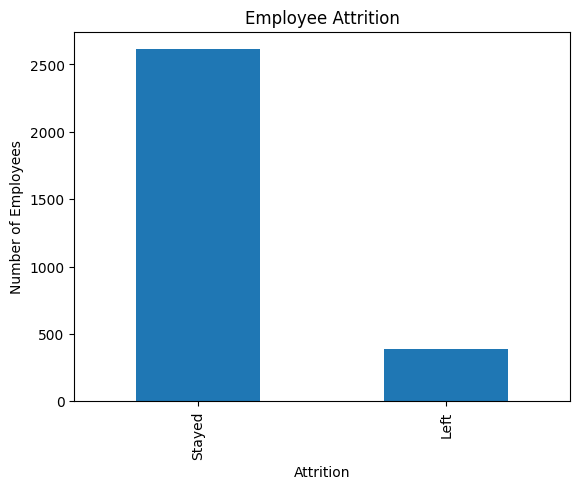

In [18]:
import matplotlib.pyplot as plt

df["Attrition"].value_counts().plot(kind="bar")

plt.title("Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

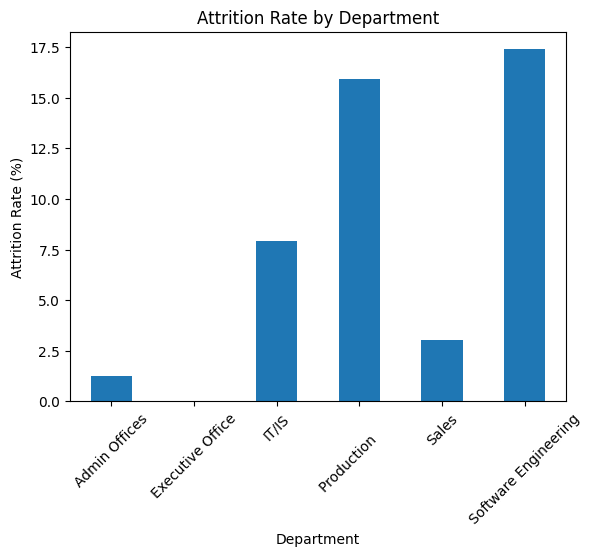

In [19]:
department_turnover["Left"].plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)
plt.show()

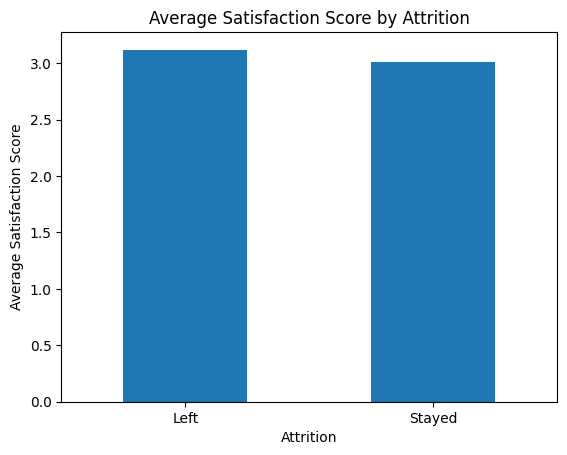

In [20]:
df.groupby("Attrition")["Satisfaction Score"].mean().plot(kind="bar")

plt.title("Average Satisfaction Score by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Satisfaction Score")
plt.xticks(rotation=0)
plt.show()

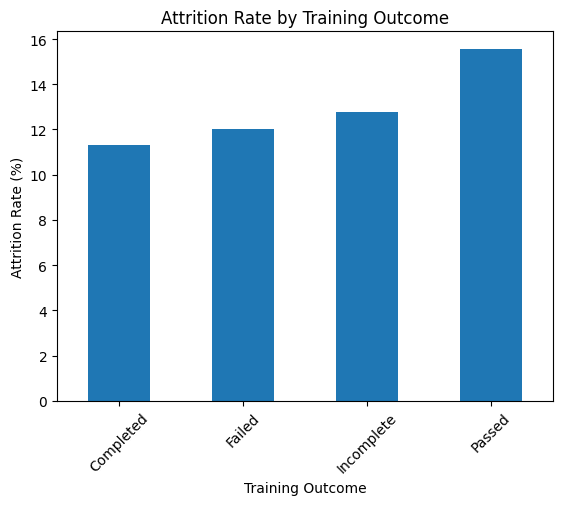

In [21]:
training_attrition["Left"].plot(kind="bar")

plt.title("Attrition Rate by Training Outcome")
plt.xlabel("Training Outcome")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [22]:
df.to_csv("cleaned_hr_data.csv", index=False)

In [23]:
from google.colab import files
files.download("cleaned_hr_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>